[![OpenSD2026 - Belgium](../../assets/OpenSD_bannerlogo.jpg)](https://www.vub.be/en/event/opensd-summer-school-belgium)

Copyright © 2026 OpenSD2026 contributors. All rights reserved. The materials in this repository are provided for educational use only and may not be copied, redistributed, or modified without prior permission. See [LICENSE](../../LICENSE).

# Modelling the Power Curve of a Wind Turbine

In this notebook, we use collected SCADA data to model the power curve of an operational wind turbine. A power curve describes the relationship between wind speed and the power produced by the turbine. This relationship depends on the turbine's controller settings and can therefore vary with the operating conditions.

We use a neural network to learn the mapping from wind speed, and later other relevant variables, to the generated power.

The goal is to understand the modelling process rather than to present the most sophisticated model. This problem can also be approached with simpler methods that are easy to implement, such as binning techniques.

# Dataset

The dataset comes from the Aventa AV-7 (6 kW) IET-OST Research Wind Turbine SCADA system.

It covers the period from 2022-01-01 to 2023-07-20 and was sampled at 1 Hz. The dataset is intended for environmental and operational analysis.

The 15 SCADA channels contain time-series observations of variables including rotor speed (RPM), generator speed (RPM), stator temperature (°C), wind speed (m/s), converter active power (kW), wind direction relative to the nacelle (degrees), 24 V system supply voltage, pitch angle (degrees), and turbine status.

Source: [Barber et al., Aventa AV-7 SCADA](https://doi.org/10.5281/zenodo.15700928), CC BY 4.0.

# Outline

1. Explore the dataset
2. Define the data splits
3. Define the neural network
4. Train a wind-speed-only model
5. Train a wind-speed-and-pitch-angle model
6. Monitor performance against a reference dataset
7. Investigate hyperparameter importance, with a focus on the learning rate

# Explore the dataset
efore doing any modelling, it is always a good idea to explore the data and make a few plots.

A simple rule to remember is:

Plot the raw data before transforming it.

A complete exploratory data analysis is outside the scope of this workshop, but in general, you should ask yourself:

- Structure: What do I actually have?
Understand the variables, their units, dimensions, sampling, and what each observation represents.
- Quality: Can I trust the data?
Look for missing values, unexpected values, gaps, outliers, or possible measurement issues.
- Intuition: Does the data make sense?
Compare what you observe with what you expect from the physics and your knowledge of the system.
- Relationships: What moves with what?
Explore how variables relate to each other and whether these relationships make physical sense.

The goal is simple: understand what you are modelling before you model it.

## Power Curve

Since we are working with wind turbine SCADA data, plotting the power curve is a natural place to start.
Additionaly, in this data a status of the turbine is available. we can also see how this status evolve

In [1]:
from pathlib import Path

import lightning as L
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, r2_score
from torch import nn
from torch.utils.data import DataLoader, Dataset

L.seed_everything(42)
plt.style.use("seaborn-v0_8-whitegrid")

Seed set to 42


In [13]:
path = Path("data/Aventa_AV7_IET_OST_SCADA_10min.parquet")
if not path.exists():
    path = Path("notebooks/04_AI_for_SHM") / path

data = pd.read_parquet(path).sort_values("Datetime").reset_index(drop=True)
print(f"{len(data):,} ten-minute windows")
print(f"{data.Datetime.min()}  →  {data.Datetime.max()}")
print(f" The columns are: {', '.join(data.columns)}")

71,262 ten-minute windows
2021-12-31 23:00:00  →  2023-07-20 21:50:00
 The columns are: Datetime, RotorSpeed_mean, GeneratorSpeed_mean, GeneratorTemperature_mean, WindSpeed_mean, PowerOutput_mean, SpeiseSpannung_mean, MaxWindHeute_mean, offsetWindDirection_mean, PitchDeg_mean, RotorSpeed_std, GeneratorSpeed_std, GeneratorTemperature_std, WindSpeed_std, PowerOutput_std, SpeiseSpannung_std, MaxWindHeute_std, offsetWindDirection_std, PitchDeg_std, StatusAnlage


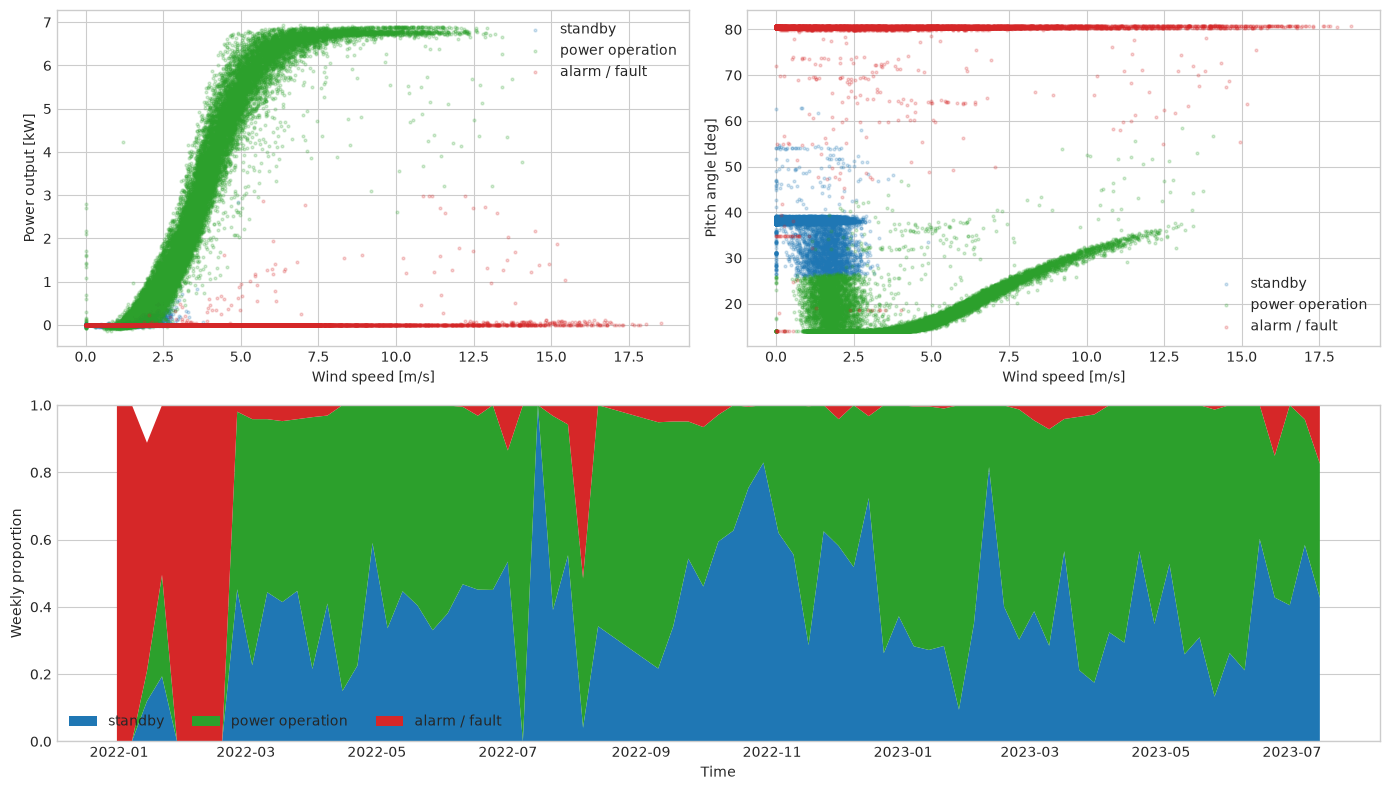

In [11]:

labels = {9: "standby", 10: "power operation", 13: "alarm / fault"}
colors = {9: "#1f77b4", 10: "#2ca02c", 13: "#d62728"}

fig, ax = plt.subplot_mosaic(
    [["power", "pitch"],
    ["status", "status"],], figsize=(14, 8),)

for state in labels:
    subset = data[data.StatusAnlage == state]
    ax["power"].scatter(subset['WindSpeed_mean'], subset['PowerOutput_mean'], s=4, alpha=.2, color=colors[state], label=labels[state])
    ax['pitch'].scatter(subset['WindSpeed_mean'], subset['PitchDeg_mean'], s=4, alpha=.2, color=colors[state], label=labels[state])
ax["power"].set(xlabel="Wind speed [m/s]", ylabel="Power output [kW]")
ax["power"].legend()
ax['pitch'].set(xlabel="Wind speed [m/s]", ylabel="Pitch angle [deg]")
ax['pitch'].legend()

timeline = data.set_index("Datetime").groupby([pd.Grouper(freq="7D"), "StatusAnlage"]).size().unstack(fill_value=0)
timeline = timeline.div(timeline.sum(axis=1), axis=0)

ax["status"].stackplot(timeline.index, *[timeline[state] for state in labels], colors=colors.values(), labels=labels.values())
ax["status"].set(xlabel="Time", ylabel="Weekly proportion", ylim=(0, 1))
ax["status"].legend(ncol=3)

plt.tight_layout()
plt.show()

At the same wind speed, the controller may permit production, hold the machine in standby, or stop it because of an alarm. No amount of model capacity can infer information that is absent from the inputs.

> **Pause and predict:** If we train one wind-only model on all three states, why would the model fail and what would be the outupt of the model on that windspeed ?

# Data Module : 
## Status split
First we will fit the model using all status to see how it fails then we will add a predictor (pitch degree) to improve the status and give the model controller information. 
In a second stage we will filter out the status 13 from the training data and see how it affected the performance 
## Splitting the data into train/val/test
The standard method for splitting time series data is to use a cutoff point in time. All data before this point becomes the training set, and all data after this point forms the test set (also sometimes called the hold-out set).


In [15]:
VAL_START = pd.Timestamp("2022-10-15")
TEST_START = pd.Timestamp("2022-12-01")
used = ["WindSpeed_mean", "PitchDeg_mean", "PowerOutput_mean", "StatusAnlage"]
data = data.dropna(subset=used).copy()

data["split"] = "train"
data.loc[data.Datetime >= VAL_START, "split"] = "val"
data.loc[data.Datetime >= TEST_START, "split"] = "test"

data.groupby("split").Datetime.agg(start="min", end="max", rows="size")

,start,end,rows
split,,,
test,2022-12-01 00:00:00,2023-07-20 21:50:00,31516
train,2021-12-31 23:00:00,2022-10-14 23:50:00,33309
val,2022-10-15 00:00:00,2022-11-30 23:50:00,6437


We suggest here using PyTorch Lightning to structure the training. PyTorch Lightning provides a higher-level interface around PyTorch that separates the model logic from the training loop. It handles common tasks such as training and validation loops, logging, checkpointing, and device management, while still relying on standard PyTorch modules.

This allows us to keep the code focused on the model architecture and the experiment itself, rather than repeatedly implementing training boilerplate while keeping the flexibility that pytorch offers compared to tensorflow and sklearn

We are about to repeat the same experiment with different feature sets. A Lightning `DataModule` keeps the split, healthy-state filter, and batching identical across models. That reproducibility—not fewer lines in this tiny example—is the benefit.

This follows Lightning's intended separation: the [DataModule](https://lightning.ai/docs/pytorch/stable/data/datamodule.html) owns data preparation and loaders; the `LightningModule` own


In [19]:
class DictDataset(Dataset):
    def __init__(self, frame, columns):
        self.data = {
            c: torch.tensor(frame[c].to_numpy()).float()
            for c in columns
        }

    def __len__(self):
        return len(next(iter(self.data.values())))

    def __getitem__(self, index):
        return {c: values[index] for c, values in self.data.items()}

In [20]:
class TurbineDataModule(L.LightningDataModule):
    def __init__(self, data, columns, query=None, batch_size=1024):
        super().__init__()
        self.data, self.columns = data, columns
        self.query, self.batch_size = query, batch_size

    def setup(self, stage=None):
        frame = self.data.query(self.query) if self.query else self.data
        self.sets = {
            split: DictDataset(frame.query("split == @split"), self.columns)
            for split in ["train", "val", "test"]
        }

    def loader(self, split, shuffle=False):
        return DataLoader(self.sets[split], batch_size=self.batch_size,
                          shuffle=shuffle, drop_last=shuffle)

    def train_dataloader(self): return self.loader("train", True)
    def val_dataloader(self): return self.loader("val")
    def test_dataloader(self): return self.loader("test")

In [22]:
columns = ["WindSpeed_mean", "PitchDeg_mean", "PowerOutput_mean"]
all_dm = TurbineDataModule(data, columns)
healthy_dm = TurbineDataModule(data, columns, query="StatusAnlage == 10")

all_dm.setup()
batch = next(iter(all_dm.train_dataloader()))
{k: value.shape for k, value in batch.items()}

{'WindSpeed_mean': torch.Size([1024]),
 'PitchDeg_mean': torch.Size([1024]),
 'PowerOutput_mean': torch.Size([1024])}

> explore the datamodule: add a cell and make some print , iterate over train_dataloader(), try to understand how it works. write test_TurbineDataModule() to test this function with a dataframe you create

Lightning Module to define the model and fitting logic

The network is a sequence of linear maps and ReLU activations. `hidden_units` controls the experiment: `(32, 32)` means two hidden layers; `(64,)` means one.

Batch normalization learns input statistics on training batches. The last layer is linear because power is a regression target.

In [ ]:
class PowerCurveNN(L.LightningModule):
    def __init__(self, input_columns, output_name: str, hidden_units=(32, 32),
                  lr=1e-3, l2_weight=1e-4, loss_fn=nn.MSELoss(), 
                  activation_fn=nn.ReLU()):
        super().__init__()
        self.save_hyperparameters()

        widths = (len(input_columns), *hidden_units)
        layers = [nn.BatchNorm1d(widths[0])]

        for n_in, n_out in zip(widths[:-1], widths[1:]):
            layers += [nn.Linear(n_in, n_out), self.hparams.activation_fn]

        self.network = nn.Sequential(*layers, nn.Linear(widths[-1], 1))
        self.loss = loss_fn

    def forward(self, x):
        return self.network(x)

    def shared_step(self, batch, stage):
        x = torch.stack([batch[c] for c in self.hparams.input_columns], dim=1)
        y = batch[self.hparams.output_name].unsqueeze(1)
        loss = self.loss(self(x), y)

        self.log(f"{stage}_loss", loss, on_step=True, 
                 on_epoch=True, batch_size=len(y))
        return loss

    def training_step(self, batch, batch_idx):
        return self.shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self.shared_step(batch, "val")

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.l2_weight)

In [40]:
from lightning.pytorch.loggers import CSVLogger

def fit_model(input_columns, output_name, name, datamodule,
              loss_fn=nn.MSELoss(), activation_fn=nn.ReLU(), l2_weight=1e-4):

    model = PowerCurveNN(
        input_columns, output_name,
        loss_fn=loss_fn,
        activation_fn=activation_fn,
        l2_weight=l2_weight
    )

    logger = CSVLogger("logs", name=name)

    trainer = L.Trainer(
        max_epochs=50,
        logger=logger,
        enable_checkpointing=False
    )

    trainer.fit(model, datamodule=datamodule)

    metrics = pd.read_csv(logger.log_dir + "/metrics.csv")

    train_loss = metrics.groupby("epoch")["train_loss_epoch"].mean()
    val_loss = metrics.groupby("epoch")["val_loss_epoch"].mean()

    plt.figure(figsize=(8, 4))
    plt.plot(train_loss, label="Train")
    plt.plot(val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    return model, logger
def predict(model, frame, columns):
    x = torch.tensor(frame[list(columns)].to_numpy()).float().to(model.device)
    model.eval()
    with torch.no_grad():
        return model(x).cpu().numpy().ravel()

def predict(model, frame, columns):
    x = torch.tensor(frame[list(columns)].to_numpy()).float().to(model.device)
    model.eval()
    with torch.no_grad():
        return model(x).cpu().numpy().ravel()


Lightning does not replace PyTorch. It organizes the steps the trainer will call. The official [LightningModule guide](https://lightning.ai/docs/pytorch/stable/common/lightning_module.html) makes the same distinction: computation stays explicit; repeated loop mechanics are automated.

## Experiment 1: Train on all states

In [41]:
all_dm = TurbineDataModule(data, columns)

/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss_fn'])`.
/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'activation_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['activation_fn'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name    | Type       | Params | Mode  | FLOPs
--------------------------------------------------

Sanity Checking DataLoader 0:  50%|█████     | 1/2 [00:00<00:00, 381.13it/s]

/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 49: 100%|██████████| 32/32 [00:00<00:00, 55.56it/s, v_num=5] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 32/32 [00:00<00:00, 55.43it/s, v_num=5]


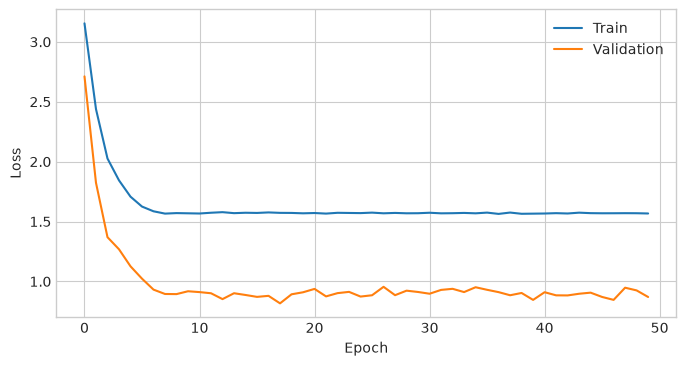

In [42]:
wind_model, wind_log = fit_model(("WindSpeed_mean",), "PowerOutput_mean", "all_states_wind", all_dm)

In [43]:
def predict(model, frame, columns):
    x = torch.tensor(frame[list(columns)].to_numpy()).float().to(model.device)
    model.eval()
    with torch.no_grad():
        return model(x).cpu().numpy().ravel()

val_data = data.query("split == 'val'").copy()
val_data["wind_error"] = (
    val_data.PowerOutput - predict(wind_model, val_data, ("WindSpeed",))
)

AttributeError: 'DataFrame' object has no attribute 'PowerOutput'

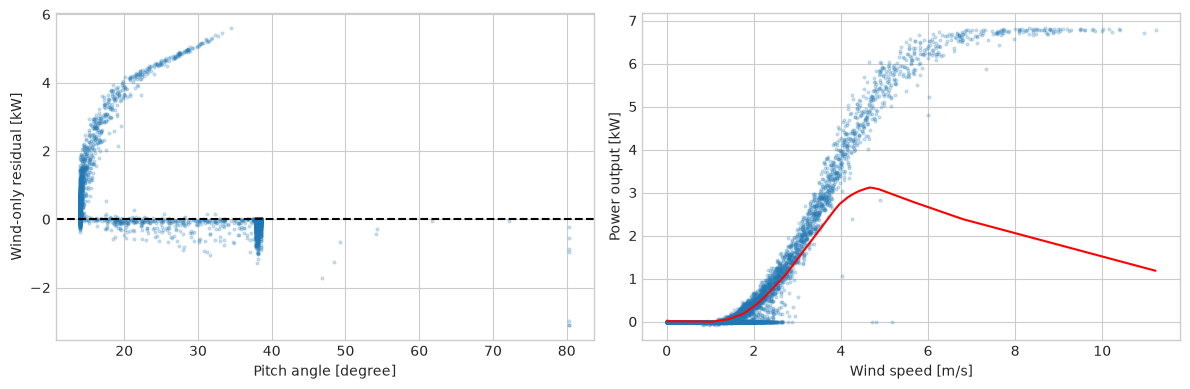

In [47]:
# Let's plot the power curve learned by the model. 
# We will use the validation set for this.
val_data = data.query("split == 'val'").copy()
val_data["wind_error"] = (
    val_data.PowerOutput_mean - predict(wind_model, val_data, ("WindSpeed_mean",))
)
fig, ax = plt.subplots(ncols=2, figsize=(12, 4))

ax[0].scatter(val_data.PitchDeg_mean, val_data.wind_error, s=4, alpha=.2)
ax[0].axhline(0, color="black", ls="--")
ax[0].set(xlabel="Pitch angle [degree]", ylabel="Wind-only residual [kW]")

val_data = val_data.sort_values("WindSpeed_mean")
wind_prediction = val_data.PowerOutput_mean - val_data.wind_error

ax[1].scatter(val_data.WindSpeed_mean, val_data.PowerOutput_mean, s=4, alpha=.2)
ax[1].plot(val_data.WindSpeed_mean, wind_prediction, color="red")
ax[1].set(xlabel="Wind speed [m/s]", ylabel="Power output [kW]")

plt.tight_layout()
plt.show()

A pattern here is evidence that pitch explains something left over after wind—not yet evidence that the final test score will improve. 
Additionaly the model in the section where the outputs is ambigouis he just learnt the weighted mean value 

/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss_fn'])`.
/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'activation_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['activation_fn'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name    | Type         | Params | Mode  | FLOPs
------------------------------------------------

/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:538: Found 1 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 49: 100%|██████████| 32/32 [00:00<00:00, 54.69it/s, v_num=0]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 32/32 [00:00<00:00, 54.51it/s, v_num=0]


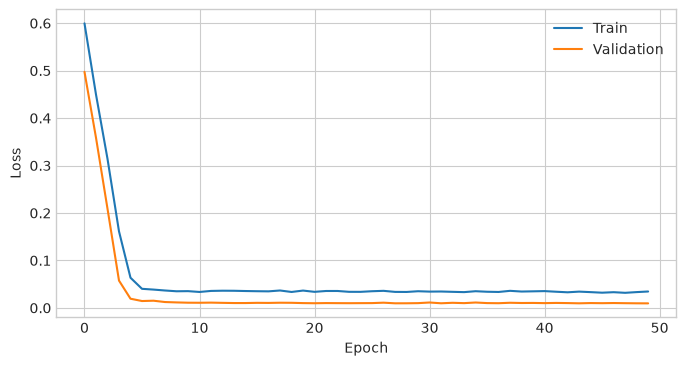

In [50]:
pitch_model, pitch_log = fit_model(
    ("WindSpeed_mean", "PitchDeg_mean"),'PowerOutput_mean', "all_states_wind_pitch", all_dm,loss_fn=nn.SmoothL1Loss()
)

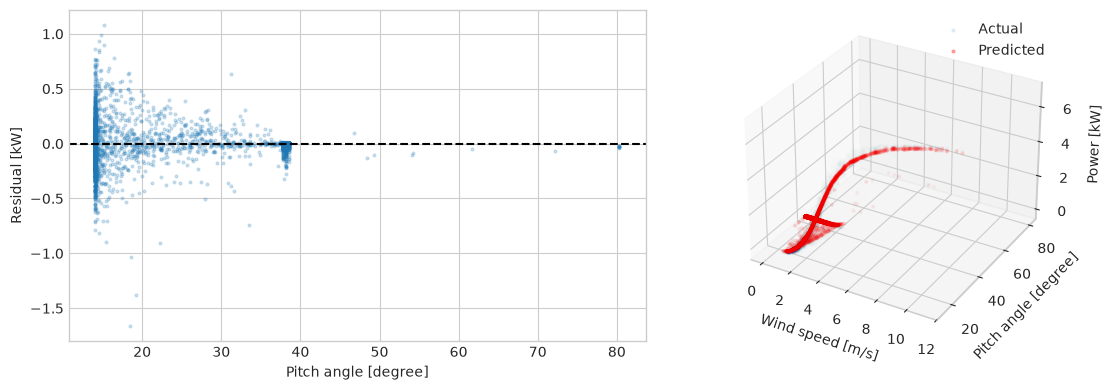

In [52]:
val_data = data.query("split == 'val'").copy()
val_data["prediction"] = predict(pitch_model, val_data, ("WindSpeed_mean", "PitchDeg_mean"))
val_data["residual"] = val_data.PowerOutput_mean - val_data.prediction

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection="3d")

ax1.scatter(val_data.PitchDeg_mean, val_data.residual, s=4, alpha=.2)
ax1.axhline(0, color="black", ls="--")
ax1.set(xlabel="Pitch angle [degree]", ylabel="Residual [kW]")

ax2.scatter(val_data.WindSpeed_mean, val_data.PitchDeg_mean, val_data.PowerOutput_mean, s=4, alpha=.1, label="Actual")
ax2.scatter(val_data.WindSpeed_mean, val_data.PitchDeg_mean, val_data.prediction, s=4, alpha=.3, color="red", label="Predicted")
ax2.set(xlabel="Wind speed [m/s]", ylabel="Pitch angle [degree]", zlabel="Power [kW]")
ax2.legend()

plt.tight_layout()
plt.show()

In [54]:
test_data = data.query("split == 'test'").copy()
y_true = test_data['PowerOutput_mean'].to_numpy()
wind_pred = predict(wind_model, test_data, ("WindSpeed_mean",))
pitch_pred = predict(pitch_model, test_data, ("WindSpeed_mean", "PitchDeg_mean"))

results = pd.DataFrame({
    "MAE": [mean_absolute_error(y_true, wind_pred),
            mean_absolute_error(y_true, pitch_pred)],
    "R2": [r2_score(y_true, wind_pred), r2_score(y_true, pitch_pred)],
}, index=["wind", "wind + pitch"])
results

,MAE,R2
wind,0.744618,0.533103
wind + pitch,0.172993,0.982474


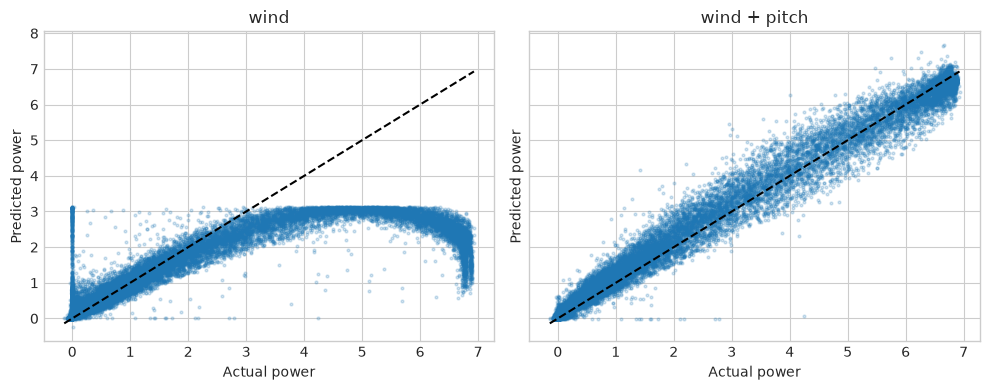

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
limits = [y_true.min(), y_true.max()]
for ax, prediction, title in zip(
    axes, [wind_pred, pitch_pred], results.index
):
    ax.scatter(y_true, prediction, s=4, alpha=.2)
    ax.plot(limits, limits, "k--")
    ax.set(title=title, xlabel="Actual power", ylabel="Predicted power")
plt.tight_layout()

If pitch improves the all-state test score, it helps describe controller-mediated output. Wind speed describes the available resource; pitch describes the controller's response. Pitch tells the model whether the blades are capturing or limiting aerodynamic power, helping separate operating conditions that wind alone cannot distinguish.

## Experiemnt 2: A separate healthy reference
For condition monitoring, fit a wind-only model on state 10. This estimates `power | wind, normal operation` and produces one interpretable curve.

/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss_fn'])`.
/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'activation_fn' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['activation_fn'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name    | Type       | Params | Mode  | FLOPs
--------------------------------------------------

/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (14) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/workspaces/OpenSD2026_Belgium/.venv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:538: Found 2 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 0:  36%|███▌      | 5/14 [00:00<00:00, 66.19it/s, v_num=1]

Epoch 49: 100%|██████████| 14/14 [00:00<00:00, 52.35it/s, v_num=1]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 14/14 [00:00<00:00, 51.70it/s, v_num=1]


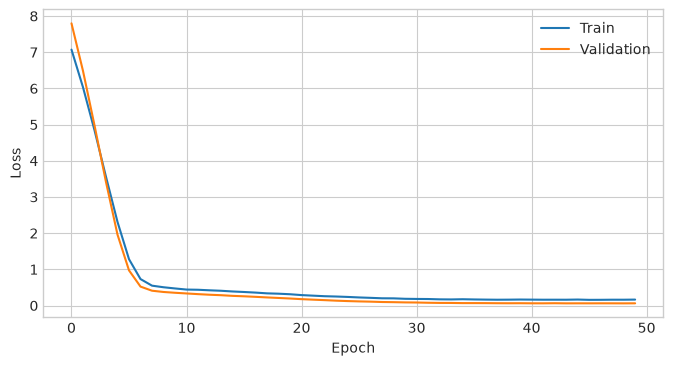

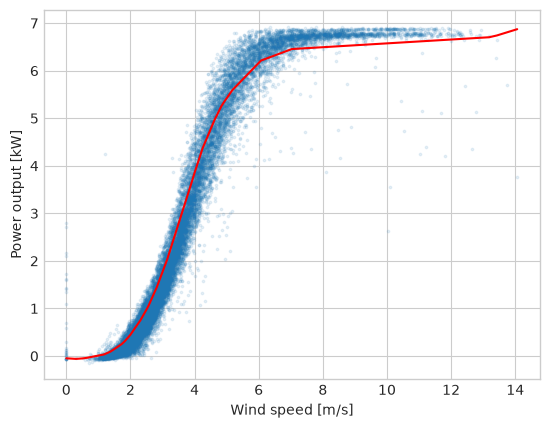

In [59]:
healthy_dm = TurbineDataModule(data, columns, query="StatusAnlage == 10")
healthy_model, healthy_log = fit_model(
    ("WindSpeed_mean",),'PowerOutput_mean', "healthy_wind", healthy_dm
)
healthy_test = data.query("split == 'test' and StatusAnlage == 10").copy()
healthy_pred = predict(healthy_model, healthy_test, ("WindSpeed_mean",))
order = np.argsort(healthy_test.WindSpeed_mean.to_numpy())

plt.scatter(healthy_test['WindSpeed_mean'], healthy_test['PowerOutput_mean'], s=3, alpha=.1)
plt.plot(healthy_test['WindSpeed_mean'].iloc[order], healthy_pred[order], color="red")
plt.xlabel("Wind speed [m/s]")
plt.ylabel("Power output [kW]")
plt.show()

In [62]:
healthy_val = data.query("split == 'val' and StatusAnlage == 10").copy()
val_prediction = predict(healthy_model, healthy_val, ("WindSpeed_mean",))
val_error = np.abs(healthy_val['PowerOutput_mean'].to_numpy() - val_prediction)
ERROR_QUANTILE = .99  # Try .95 and .999
threshold = np.quantile(val_error, ERROR_QUANTILE)
threshold

np.float64(0.7187796116500383)

In [64]:
monitor = data.query("split == 'test'").sort_values("Datetime").copy()
monitor["expected"] = predict(healthy_model, monitor, ("WindSpeed_mean",))
monitor["error"] = (monitor.PowerOutput_mean - monitor.expected).abs()
monitor["trigger"] = monitor.error > threshold

In [65]:
alarm = monitor.StatusAnlage.eq(13)
fig = go.Figure()
fig.add_trace(go.Scattergl(
    x=monitor.Datetime, y=monitor.error, mode="lines",
    line={"width": .6}, opacity=.45, name="absolute residual",
))
fig.add_trace(go.Scattergl(
    x=monitor.loc[alarm, "Datetime"], y=monitor.loc[alarm, "error"],
    mode="markers", marker={"size": 4, "color": "red"}, name="state 13",
))
fig.add_hline(y=threshold, line_dash="dash", annotation_text="threshold")
fig.update_layout(xaxis_title="Time",
                  yaxis_title="Absolute power residual [kW]")
fig.show()

In [66]:
monitor.groupby("StatusAnlage").agg(
    windows=("error", "size"),
    median_error=("error", "median"),
    trigger_rate=("trigger", "mean"),
)

,windows,median_error,trigger_rate
StatusAnlage,,,
9.0,11819,0.055010,0.017260
10.0,19047,0.226710,0.076075
13.0,650,1.975312,0.609231


### Is deep learning necessary here?

No. For a small tabular problem with one or two inputs, a decision tree, boosted trees, a spline, or a standard power-curve model may perform as well while being faster and easier to interpret. We use a neural network here to learn the PyTorch/Lightning workflow and to make feature and architecture experiments easy. Deep learning becomes more compelling when many sensors, turbines, or more complex temporal relationships are modelled together.

## What to remember

- Wind speed does not identify controller state.
- A power curve answers `power | wind, normal operation`, not power under every condition.
- Keep train, validation, and future test roles separate.
- A batch is `[observations, features]`.
- Lightning helps organizes PyTorch experiments

# Investigate hyperparameter importance, with a focus on the learning rate
Let's investigate the impact of different hyperparamteres on the model's performance, particularly focusing on the learning rate. We will train multiple models with varying learning rates and compare their validation losses to determine the optimal learning rate for our neural network. 

In [ ]:
# Hyperparameter study: change one choice at a time from the baseline
experiments = {
    "baseline": {"hidden_units": (32, 32), "loss_fn": nn.MSELoss(), "l2_weight": 1e-4, "lr": 1e-3},
    "low LR": {"hidden_units": (32, 32), "loss_fn": nn.MSELoss(), "l2_weight": 1e-4, "lr": 1e-4},
    "mid LR": {"hidden_units": (32, 32), "loss_fn": nn.MSELoss(), "l2_weight": 1e-4, "lr": 1e-3},
    "high LR": {"hidden_units": (32, 32), "loss_fn": nn.MSELoss(), "l2_weight": 1e-4, "lr": 1e-2},
    "SmoothL1 loss": {"hidden_units": (32, 32), "loss_fn": nn.SmoothL1Loss(), "l2_weight": 1e-4, "lr": 1e-3},
    "small model": {"hidden_units": (8,), "loss_fn": nn.MSELoss(), "l2_weight": 1e-4, "lr": 1e-3},
    "large model": {"hidden_units": (64, 64, 32), "loss_fn": nn.MSELoss(), "l2_weight": 1e-4, "lr": 1e-3},
    "no L2": {"hidden_units": (32, 32), "loss_fn": nn.MSELoss(), "l2_weight": 0, "lr": 1e-3},
    "strong L2": {"hidden_units": (32, 32), "loss_fn": nn.MSELoss(), "l2_weight": 1e-1, "lr": 1e-3},
}

scores = []
validation = data.query("split == 'val'")

for name, settings in experiments.items():
    L.seed_everything(42)
    trial_model = PowerCurveNN(("WindSpeed_mean", "PitchDeg_mean"),'PowerOutput_mean', **settings)
    trial_trainer = L.Trainer(max_epochs=30, logger=False, enable_checkpointing=False, enable_progress_bar=False)
    trial_trainer.fit(trial_model, datamodule=all_dm)
    prediction = predict(trial_model, validation, ("WindSpeed_mean", "PitchDeg_mean"))
    scores.append({"experiment": name, "MAE": mean_absolute_error(validation.PowerOutput_mean, prediction), "R2": r2_score(validation.PowerOutput_mean, prediction)})

hyperparameter_results = pd.DataFrame(scores).set_index("experiment")
display(hyperparameter_results.sort_values("MAE"))
hyperparameter_results.plot.bar(subplots=True, figsize=(10, 5), rot=30, legend=False)
plt.tight_layout()
plt.show()

Seed set to 42


TypeError: PowerCurveNN.__init__() missing 1 required positional argument: 'output_name'

### Observations

The baseline already performs well. Changing the learning rate has the largest effect: a low learning rate converges too slowly within 30 epochs, while a high learning rate makes optimization unstable. The middle learning rate gives performance close to the baseline.

The small model underfits, whereas the larger model gives only a small improvement. Smooth L1 performs similarly to MSE, suggesting that outliers are not dominating this validation set. L2 regularization has little effect at its default strength, but strong L2 slightly reduces performance.

These conclusions are based on one split and one random seed, so small differences should not be overinterpreted.